# Étude d'une unité de liquéfaction d'$H_2$

In [141]:
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP
import seaborn as sns
import pandas as pd
sns.set_style()

## Question 1

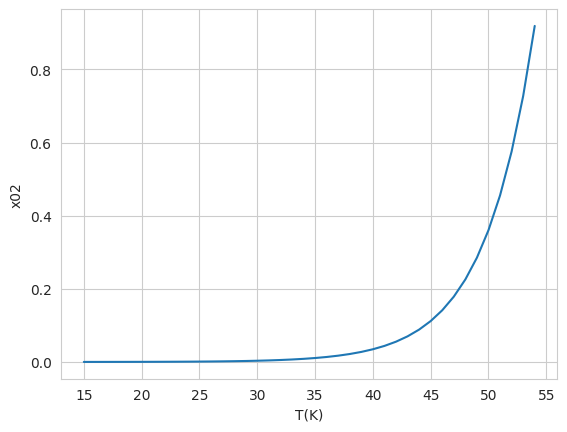

In [142]:
delta_h_1 = 0.445
#delta_h_2 = 0.743
#delta_h_3 = 0.094
T1 = 54.361
#T2 = 43.772
#T3 = 23.781
R = 8.314
T = np.arange(15,55,1) # T va de 15 à 54, pas de 1
A = 334527*np.exp(-0.234*T)
x_O2 = 1/A * np.exp(delta_h_1/R/T1*(1-T1/T))

plt.plot(T,x_O2)
plt.xlabel('T(K)')
plt.ylabel('x02')
plt.show()

Solubilité de O2(s) à la température finale de liquéfaction de H2 (20.65K)?

In [143]:
Tf = 20.65
A = 334527*np.exp(-0.234*Tf)
x_O2f = 1/A * np.exp(delta_h_1/R/T1*(1-T1/Tf))
print(x_O2f)

0.0003744769759273762


## Question 2

question 2 
La solubilité de l'oxygène solide est donc de 0.03745%.
Or, en sortie de l'électrolyseur, la fraction molaire de dioxygène résiduel est égale à 1000ppm, soit 0.1%. Cette concentration présente donc un risque de cristallisation à la température finale de liquéfaction de l'H2.
Il y a un rapport 2.67 entre ces deux valeurs, ce qui correspond au taux de purification minimale qui doit être pris en compte pour le design de l'unité de purification.

## Question 3

question 3
A rédiger

## Question 4

In [144]:
#question 4 
T1 = 298.15
P1 = 1.1e5

table = {
    "Oxygen": {},
    "Nitrogen": {},
    "Methane": {},
    "Hydrogen": {}
}


for fluide in table.keys():
    h1 = CP.PropsSI ('H', 'P', P1, 'T', T1, fluide) #on récupère h1(fluide)
    s1 = CP.PropsSI ('S', 'P', P1, 'T', T1, fluide) #on récupère s1(fluide)
    h3 = CP.PropsSI ('H', 'P', P1, 'Q', 0 , fluide) # on récupère l'enthalpie sur la courbe d'ébullition (hyp : le gaz est entièrement liq)
    s3 = CP.PropsSI ('S', 'P', P1, 'Q', 0 , fluide) #on récupère s1(fluide)

    travail = h3 - h1 -T1*(s3-s1)
    table[fluide]["travail"] = travail

print(table)
    

{'Oxygen': {'travail': 619368.0219534623}, 'Nitrogen': {'travail': 750325.2923288424}, 'Methane': {'travail': 1061584.7249901756}, 'Hydrogen': {'travail': 11844314.30563906}}


## Question 5

question 5 
à remplir cf photo

## Question 6

## Question 8

In [145]:
table = {
    "Oxygen": {},
    "Nitrogen": {},
    "Methane": {},
    "Hydrogen": {}
}

P1 = 50e5
T1 = 298.15
P = 1.1e5

for fluide in table.keys():
    h1 = CP.PropsSI('H', 'P', P1, 'T', T1, fluide)
    s1 = CP.PropsSI('S', 'P', P1, 'T', T1, fluide)

    # Détente isenthalpique
    T_f = CP.PropsSI('T', 'P', P, 'H', h1, fluide)
    
    table[fluide]["T_f"] = T_f
    table[fluide]["delta_T"] = T_f - T1

table

{'Oxygen': {'T_f': 285.14017910661016, 'delta_T': -13.009820893389815},
 'Nitrogen': {'T_f': 288.19408139852175, 'delta_T': -9.955918601478231},
 'Methane': {'T_f': 275.8774905819851, 'delta_T': -22.272509418014863},
 'Hydrogen': {'T_f': 299.68076399649055, 'delta_T': 1.5307639964905775}}

!! Rédiger !!
Delta T < 0 pour tout les gaz sauf l'hydrogène, ce qui signifie que les gaz se refroidissent lors de la détente, tandis que l'hydrogène se réchauffe.

## Question 9

On implémente le tableau avec les données fournies.

In [146]:
table = {
    "A" : {},
    "B" : {},
    "C" : {},
    "D" : {},
    "E" : {},
    "F" : {},
    "G" : {},
    "H" : {},
    "I" : {},
    "J" : {},
    "K" : {},
    "L_rev" : {},
    "L_irrev" : {},
    "M" : {},
    "N" : {},
    "O_rev" : {},
    "O_irrev" : {},
    "P" : {}
}

for point in table.keys():
    table[point]["Débit"] = float
    table[point]["Température"] = float
    table[point]["Pression"] = float
    table[point]["Enthalpie"] = float
    table[point]["Entropie"] = float
    table[point]["Titre"] = float

In [147]:
table["A"]["Débit"] = 100
table["A"]["Température"] = 298.15
table["A"]["Pression"] = 30
table["A"]["Titre"] = 1

table["C"]["Température"] = 110

table["E"]["Température"] = 50

table["G"]["Température"] = 20.65
table["G"]["Pression"] = 1.1
table["G"]["Titre"] = 0.7

table["H"]["Titre"] = 0

table["I"]["Titre"] = 1

Les conservations de la masse autour des mélangeurs et du séparateur s'écrivent :
$$
\begin{cases}
\dot{m}_A + \dot{m}_P = \dot{m}_B\\
\dot{m}_C = \dot{m}_D + \dot{m}_K\\
\dot{m}_G = \dot{m}_H + \dot{m}_I\\
\dot{m}_J + \dot{m}_L = \dot{m}_M
\end{cases}
$$

Les données des taux de fractionnement du points $C$ et de séparation du point $G$ permettent d'écrire :

$$\begin{cases}
\dot{m}_D = \frac{85}{100} \dot{m}_C\\
\dot{m}_I = \frac{70}{100} \dot{m}_G
\end{cases}$$

On peut donc calculer les débits massiques :

In [148]:
table["H"]["Débit"] = table["A"]["Débit"]

table["G"]["Débit"] = table["H"]["Débit"]/(1-table["G"]["Titre"])
table["I"]["Débit"] = table["G"]["Débit"]*(table["G"]["Titre"])

table["J"]["Débit"] = table["I"]["Débit"]

table["F"]["Débit"] = table["E"]["Débit"] = table["D"]["Débit"] = table["G"]["Débit"]

table["C"]["Débit"] = (100/85)*table["D"]["Débit"]
table["B"]["Débit"] = table["C"]["Débit"]

table["P"]["Débit"] = table["B"]["Débit"] - table["A"]["Débit"]

table["O_rev"]["Débit"] = table["O_irrev"]["Débit"] = table["N"]["Débit"] = table["M"]["Débit"] = table["P"]["Débit"]

table["L_rev"]["Débit"] = table["M"]["Débit"] - table["J"]["Débit"]

table["L_irrev"]["Débit"] = table["K"]["Débit"] = table["L_rev"]["Débit"]

On vérifie ensuite la conservation de la masse autour du mélangeur $C$ (l'équation n'ayant pas été utilisée pour le calcul des débits massiques) :

In [149]:
if table["K"]["Débit"] + table["D"]["Débit"] == table["C"]["Débit"] :
    print("Conservation de la masse vérifiée")

Conservation de la masse vérifiée


In [150]:
df = pd.DataFrame(table)
df = df.transpose()
df

,Débit,Température,Pression,Enthalpie,Entropie,Titre
A,100,298.15,30,<class 'float'>,<class 'float'>,1
B,392.156863,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>
C,392.156863,110,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>
D,333.333333,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>
E,333.333333,50,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>
F,333.333333,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>
G,333.333333,20.65,1.1,<class 'float'>,<class 'float'>,0.7
H,100,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,0
I,233.333333,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,1
J,233.333333,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>
